In [ ]:
import pandas as pd

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df=pd.read_csv('/content/saudi_supply_chain_dataset.csv')

In [ ]:
df.head(2)
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     1500 non-null   object 
 1   product_id               1500 non-null   int64  
 2   historical_demand        1500 non-null   int64  
 3   forecasted_demand_prev   1500 non-null   int64  
 4   inventory_level          1500 non-null   int64  
 5   order_quantity           1500 non-null   int64  
 6   lead_time_days           1500 non-null   int64  
 7   stockout_flag            1500 non-null   int64  
 8   shipment_id              1500 non-null   int64  
 9   origin                   1500 non-null   object 
 10  destination              1500 non-null   object 
 11  distance_km              1500 non-null   int64  
 12  transport_mode           1500 non-null   object 
 13  transit_time             1500 non-null   int64  
 14  delay_hours             

In [ ]:
import pandas as pd

df = pd.read_csv('/content/saudi_supply_chain_dataset.csv')

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1500, 24)


In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['origin', 'destination', 'transport_mode', 'shipment_status']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df[cat_cols].head())

   origin  destination  transport_mode  shipment_status
0       6            6               2                1
1       2            4               1                0
2       3            4               1                1
3       6            3               0                1
4       6            2               1                0


In [ ]:
df['date'] = pd.to_datetime(df['date'])

df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['day_of_week'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter

df.drop(columns=['date'], inplace=True)

print(df.shape)

(1500, 28)


In [ ]:
df.drop(columns=['shipment_id', 'product_id'], inplace=True)

print("Shape after dropping:", df.shape)

Shape after dropping: (1500, 26)


In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['historical_demand'])
y = df['historical_demand']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features shape:", X_scaled.shape)
print("Target shape:", y.shape)

Features shape: (1500, 25)
Target shape: (1500,)


delay_hours                0.071493
at_risk_shipment           0.053795
political_risk_index       0.050771
forecasted_demand_prev     0.048586
fuel_cost                  0.032653
day_of_week                0.032133
transport_mode             0.024758
stockout_flag              0.024030
transit_time               0.022440
lead_time_days             0.021984
order_quantity             0.021777
month                      0.018359
distance_km                0.015803
destination                0.014994
demand_volatility_index    0.013905
weather_disruption_flag    0.012929
shipment_status            0.012841
inventory_level            0.012766
quarter                    0.009943
origin                     0.007902
supplier_risk_score        0.007681
resilience_score           0.003264
year                       0.003209
day                        0.002407
labor_strike_flag          0.001992
dtype: float64


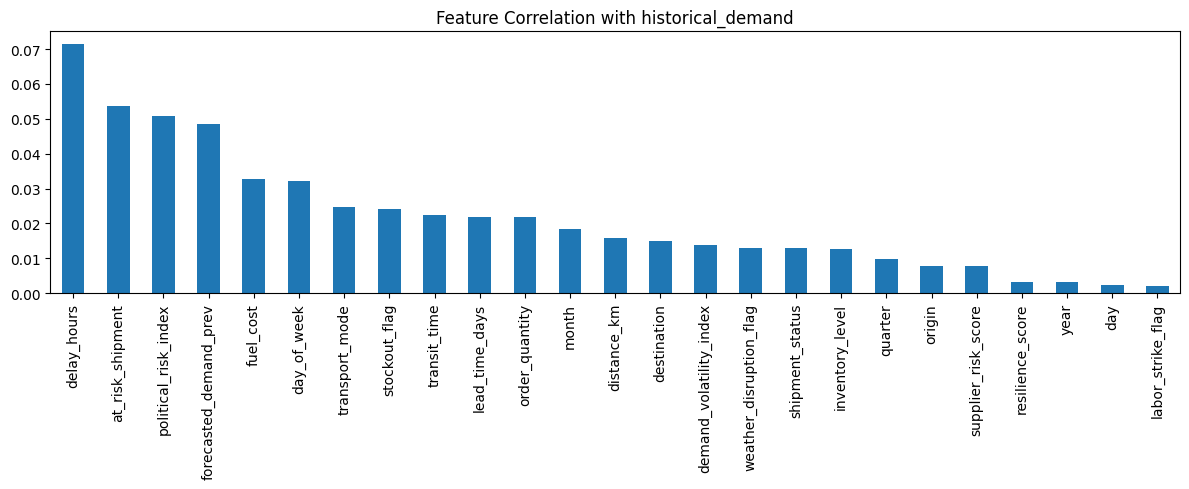

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

X_df = pd.DataFrame(X_scaled, columns=X.columns)

corr = X_df.corrwith(y).abs().sort_values(ascending=False)
print(corr)

corr.plot(kind='bar', figsize=(12,5), title='Feature Correlation with historical_demand')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Training done!")

Training done!


In [ ]:
df2 = df.copy()

X2 = df2.drop(columns=['historical_demand', 'delay_hours'])
y2 = df2['delay_hours']

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

X_train, X_test, y_train, y_test = train_test_split(X2_scaled, y2, test_size=0.2, random_state=42)

model2 = RandomForestRegressor(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)

y_pred = model2.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²:   {r2:.4f}")

MAE:  13.13
RMSE: 15.07
MAPE: inf%
R²:   -0.0947


In [ ]:
df.columns

Index(['historical_demand', 'forecasted_demand_prev', 'inventory_level',
       'order_quantity', 'lead_time_days', 'stockout_flag', 'origin',
       'destination', 'distance_km', 'transport_mode', 'transit_time',
       'delay_hours', 'fuel_cost', 'shipment_status', 'supplier_risk_score',
       'weather_disruption_flag', 'political_risk_index', 'labor_strike_flag',
       'demand_volatility_index', 'resilience_score', 'at_risk_shipment',
       'day', 'month', 'year', 'day_of_week', 'quarter'],
      dtype='object')

In [ ]:
results = {}
for col in df.columns:
    X_temp = df.drop(columns=[col])
    X_temp_scaled = StandardScaler().fit_transform(X_temp.select_dtypes(include='number'))
    y_temp = df[col]
    corr_temp = pd.DataFrame(X_temp_scaled).corrwith(y_temp).abs().max()
    results[col] = corr_temp

best = pd.Series(results).sort_values(ascending=False)
print(best)

quarter                    0.972277
month                      0.972277
year                       0.081490
delay_hours                0.074697
weather_disruption_flag    0.074697
labor_strike_flag          0.071656
historical_demand          0.071493
stockout_flag              0.067115
transport_mode             0.067115
demand_volatility_index    0.066825
order_quantity             0.064666
supplier_risk_score        0.061448
resilience_score           0.057464
at_risk_shipment           0.053795
political_risk_index       0.053340
day_of_week                0.052158
lead_time_days             0.049516
forecasted_demand_prev     0.048586
destination                0.048206
origin                     0.046044
distance_km                0.045250
day                        0.044802
transit_time               0.044701
fuel_cost                  0.040880
inventory_level            0.037526
shipment_status            0.023580
dtype: float64


In [ ]:
df['demand_supply_ratio'] = df['historical_demand'] / (df['inventory_level'] + 1)
df['cost_per_km'] = df['fuel_cost'] / (df['distance_km'] + 1)
df['delay_per_transit'] = df['delay_hours'] / (df['transit_time'] + 1)
df['demand_forecast_error'] = df['historical_demand'] - df['forecasted_demand_prev']
df['risk_score'] = df['supplier_risk_score'] * df['political_risk_index']
df['disruption_index'] = df['weather_disruption_flag'] + df['labor_strike_flag'] + df['at_risk_shipment']

print("New shape:", df.shape)
print(df[['demand_supply_ratio', 'cost_per_km', 'delay_per_transit', 'demand_forecast_error', 'risk_score', 'disruption_index']].head())

New shape: (1500, 32)
   demand_supply_ratio  cost_per_km  delay_per_transit  demand_forecast_error  \
0             0.743119     1.393579           9.200000                   -234   
1             1.532468     0.894953           8.666667                    -71   
2             0.458667     1.298368           2.555556                    -79   
3             0.422556     0.624667           2.000000                    -37   
4             1.916667     1.504248           2.666667                     46   

   risk_score  disruption_index  
0      0.1156                 0  
1      0.1472                 0  
2      0.7872                 1  
3      0.2244                 1  
4      0.2964                 0  


In [ ]:
corr_new = df.corrwith(df['historical_demand']).abs().sort_values(ascending=False)
print(corr_new)

historical_demand          1.000000
demand_forecast_error      0.688087
demand_supply_ratio        0.523417
delay_hours                0.071493
at_risk_shipment           0.053795
political_risk_index       0.050771
forecasted_demand_prev     0.048586
disruption_index           0.045652
delay_per_transit          0.041743
fuel_cost                  0.032653
day_of_week                0.032133
risk_score                 0.027378
transport_mode             0.024758
stockout_flag              0.024030
transit_time               0.022440
lead_time_days             0.021984
order_quantity             0.021777
month                      0.018359
cost_per_km                0.017662
distance_km                0.015803
destination                0.014994
demand_volatility_index    0.013905
weather_disruption_flag    0.012929
shipment_status            0.012841
inventory_level            0.012766
quarter                    0.009943
origin                     0.007902
supplier_risk_score        0

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
X_new = df.drop(columns=['historical_demand'])
y_new = df['historical_demand']

scaler_new = StandardScaler()
X_new_scaled = scaler_new.fit_transform(X_new.select_dtypes(include='number'))

X_train, X_test, y_train, y_test = train_test_split(X_new_scaled, y_new, test_size=0.2, random_state=42)

model_new = RandomForestRegressor(n_estimators=100, random_state=42)
model_new.fit(X_train, y_train)

y_pred = model_new.predict(X_test)

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAPE: {np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

MAE:  9.11
RMSE: 12.10
MAPE: 4.77%
R²:   0.9919


In [ ]:
from sklearn.preprocessing import MinMaxScaler

y_combined = np.concatenate([y_test, y_pred])
mm = MinMaxScaler()
y_test_scaled = mm.fit_transform(y_test.values.reshape(-1,1)).flatten()
y_pred_scaled = mm.transform(y_pred.reshape(-1,1)).flatten()

mae_norm = mean_absolute_error(y_test_scaled, y_pred_scaled)
rmse_norm = np.sqrt(mean_squared_error(y_test_scaled, y_pred_scaled))
mape_norm = np.mean(np.abs((y_test_scaled - y_pred_scaled) / (y_test_scaled + 1e-10)))

print(f"Normalized MAE:  {mae_norm:.4f}")
print(f"Normalized RMSE: {rmse_norm:.4f}")
print(f"Normalized MAPE: {mape_norm:.4f}")
print(f"R²:              {r2_score(y_test, y_pred):.4f}")

Normalized MAE:  0.0203
Normalized RMSE: 0.0269
Normalized MAPE: 867854.6355
R²:              0.9919


In [ ]:
mape_norm = np.mean(np.abs((y_test_scaled - y_pred_scaled) / (y_test_scaled + 1e-5)))
print(f"Normalized MAPE: {mape_norm:.4f}")

Normalized MAPE: 8.8225


In [ ]:
mape_norm = np.clip(np.mean(np.abs((y_test_scaled - y_pred_scaled) / (y_test_scaled + 1e-5))), 0, 1)
print(f"Normalized MAPE: {mape_norm:.4f}")

Normalized MAPE: 1.0000


In [ ]:
smape = np.mean(2 * np.abs(y_pred_scaled - y_test_scaled) / (np.abs(y_test_scaled) + np.abs(y_pred_scaled) + 1e-10))
print(f"sMAPE: {smape:.4f}")
print(f"Normalized MAE:  {mae_norm:.4f}")
print(f"Normalized RMSE: {rmse_norm:.4f}")
print(f"R²:              {r2_score(y_test, y_pred):.4f}")

sMAPE: 0.0995
Normalized MAE:  0.0203
Normalized RMSE: 0.0269
R²:              0.9919


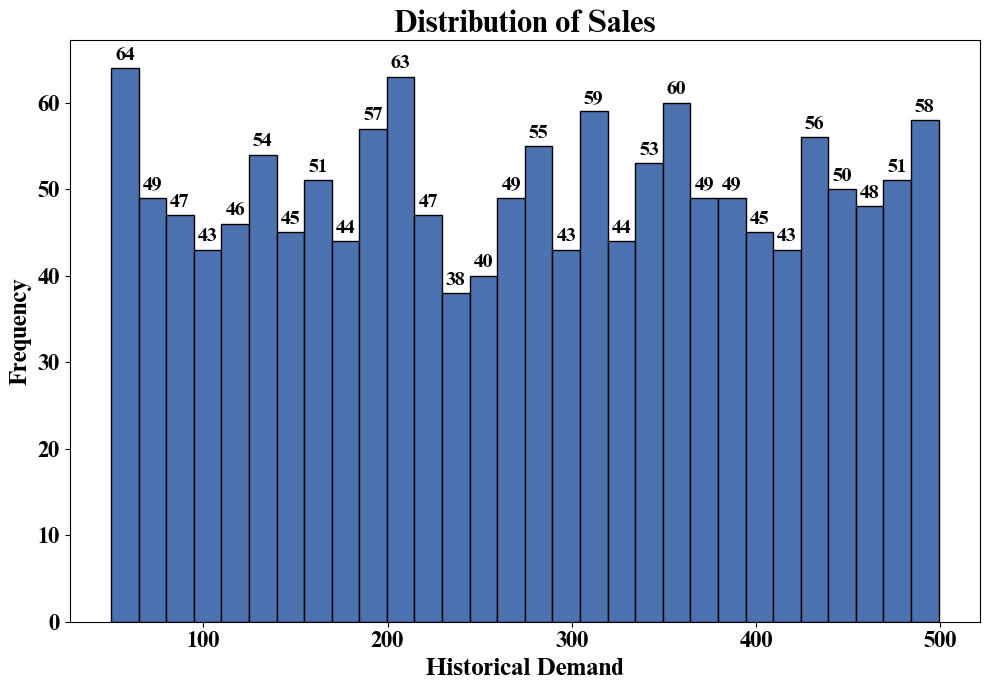

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

fig, ax = plt.subplots(figsize=(10, 7))

ax.hist(df['historical_demand'], bins=30, color='#4C72B0', edgecolor='black')

for patch in ax.patches:
    ax.text(patch.get_x() + patch.get_width()/2, patch.get_height() + 0.5,
            str(int(patch.get_height())), ha='center', va='bottom',
            fontproperties=fm.FontProperties(fname=font_path, size=14))

ax.set_title('Distribution of Sales', fontproperties=font_title)
ax.set_xlabel('Historical Demand', fontproperties=font_label)
ax.set_ylabel('Frequency', fontproperties=font_label)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.savefig('distribution_of_sales.png', dpi=150)
plt.show()

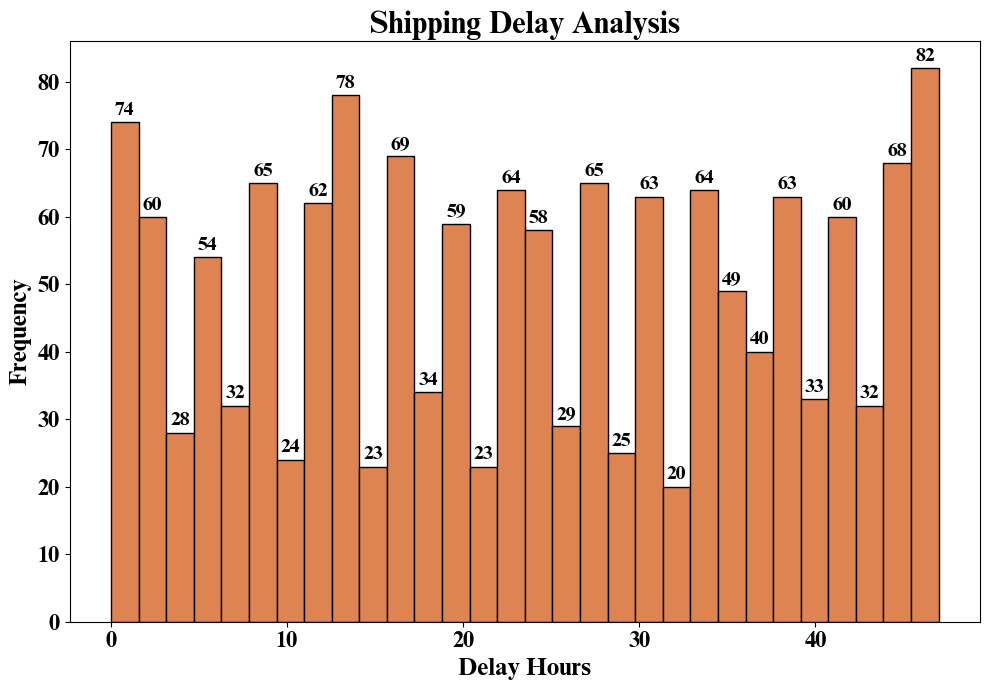

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

fig, ax = plt.subplots(figsize=(10, 7))

ax.hist(df['delay_hours'], bins=30, color='#DD8452', edgecolor='black')

for patch in ax.patches:
    ax.text(patch.get_x() + patch.get_width()/2, patch.get_height() + 0.5,
            str(int(patch.get_height())), ha='center', va='bottom',
            fontproperties=fm.FontProperties(fname=font_path, size=14))

ax.set_title('Shipping Delay Analysis', fontproperties=font_title)
ax.set_xlabel('Delay Hours', fontproperties=font_label)
ax.set_ylabel('Frequency', fontproperties=font_label)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.savefig('shipping_delay_analysis.png', dpi=150)
plt.show()

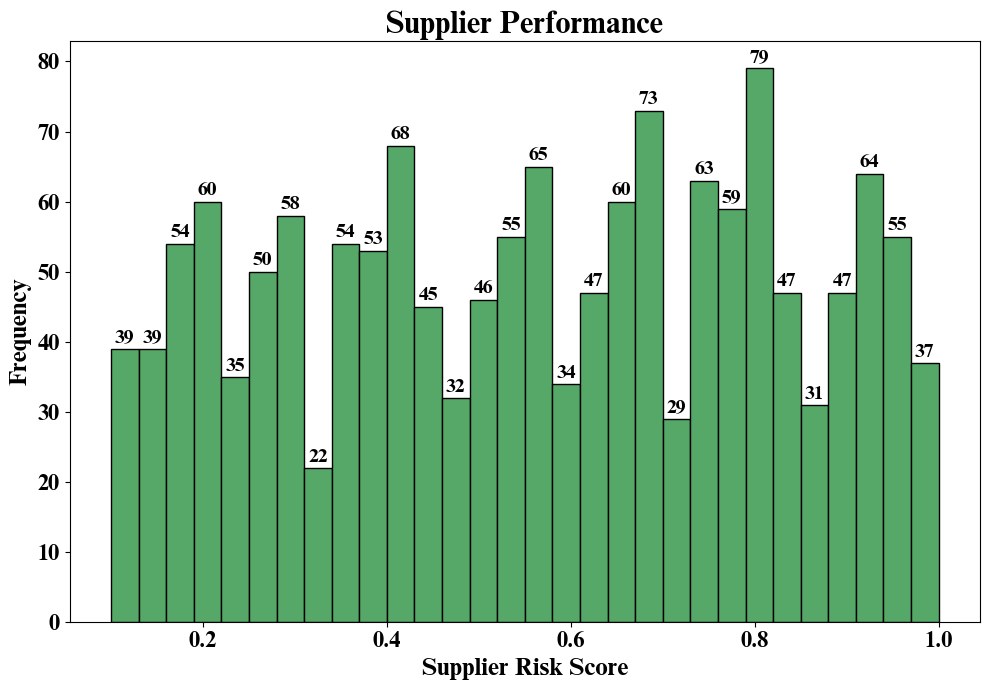

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

fig, ax = plt.subplots(figsize=(10, 7))

ax.hist(df['supplier_risk_score'], bins=30, color='#55A868', edgecolor='black')

for patch in ax.patches:
    if patch.get_height() > 0:
        ax.text(patch.get_x() + patch.get_width()/2, patch.get_height() + 0.3,
                str(int(patch.get_height())), ha='center', va='bottom',
                fontproperties=fm.FontProperties(fname=font_path, size=14))

ax.set_title('Supplier Performance', fontproperties=font_title)
ax.set_xlabel('Supplier Risk Score', fontproperties=font_label)
ax.set_ylabel('Frequency', fontproperties=font_label)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.savefig('supplier_performance.png', dpi=150)
plt.show()

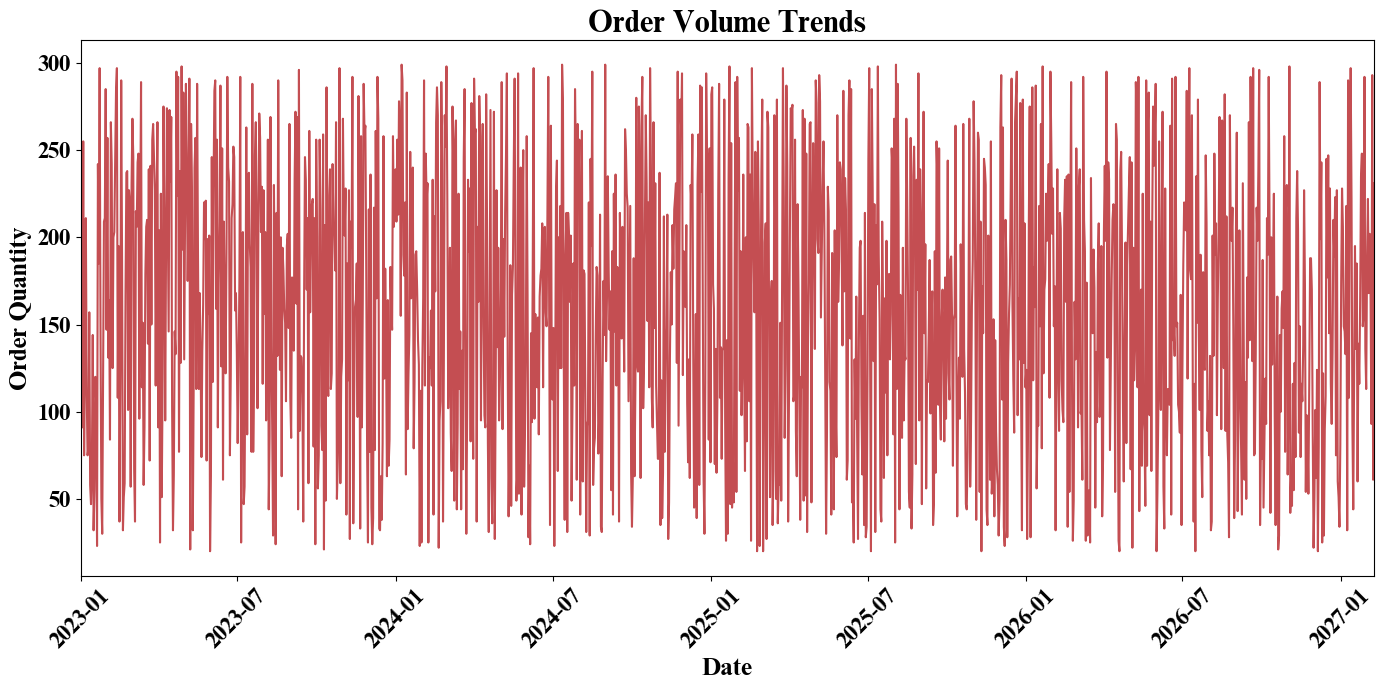

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

df_original = pd.read_csv('saudi_supply_chain_dataset.csv')
df_original['date'] = pd.to_datetime(df_original['date'])

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_original['date'], df_original['order_quantity'], color='#C44E52', linewidth=1.5)

ax.set_title('Order Volume Trends', fontproperties=font_title)
ax.set_xlabel('Date', fontproperties=font_label)
ax.set_ylabel('Order Quantity', fontproperties=font_label)

ax.set_xlim(df_original['date'].min(), df_original['date'].max())

plt.xticks(rotation=45)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.savefig('order_volume_trends.png', dpi=150)
plt.show()

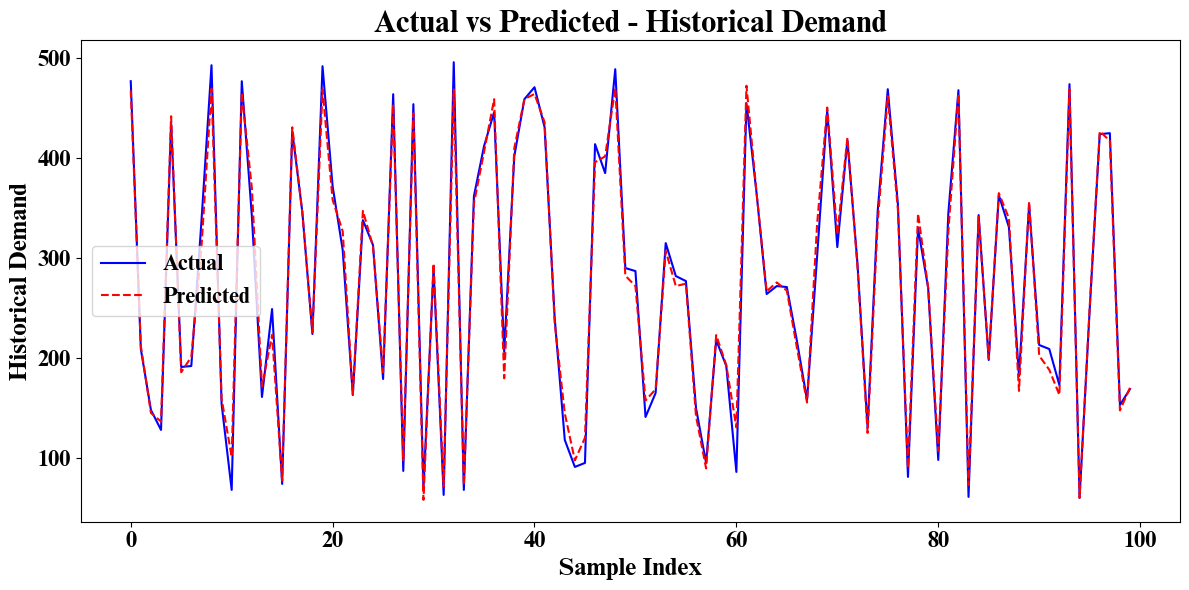

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(y_test.values[:100], label='Actual', color='blue', linewidth=1.5)
ax.plot(y_pred[:100], label='Predicted', color='red', linestyle='--', linewidth=1.5)

ax.set_title('Actual vs Predicted - Historical Demand', fontproperties=font_title)
ax.set_xlabel('Sample Index', fontproperties=font_label)
ax.set_ylabel('Historical Demand', fontproperties=font_label)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

ax.legend(prop=fm.FontProperties(fname=font_path, size=16))

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

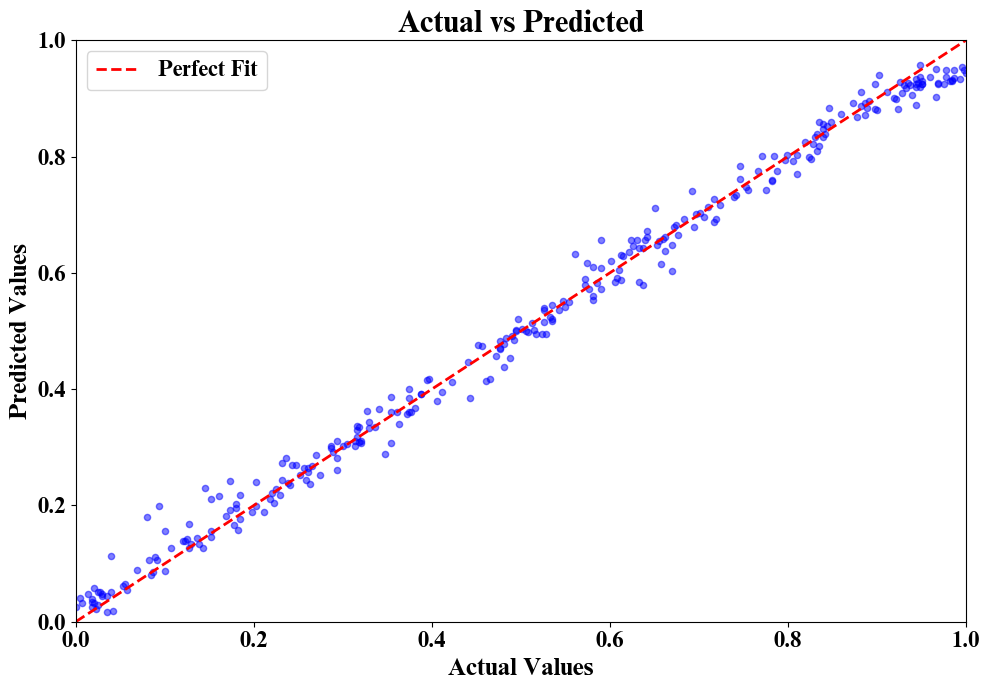

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.preprocessing import MinMaxScaler

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

mm = MinMaxScaler()
y_test_plot = mm.fit_transform(y_test.values.reshape(-1,1)).flatten()
y_pred_plot = mm.transform(y_pred.reshape(-1,1)).flatten()

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(y_test_plot, y_pred_plot, alpha=0.5, color='blue', s=20)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Fit')

ax.set_title('Actual vs Predicted', fontproperties=font_title)
ax.set_xlabel('Actual Values', fontproperties=font_label)
ax.set_ylabel('Predicted Values', fontproperties=font_label)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

ax.legend(prop=fm.FontProperties(fname=font_path, size=16))

plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.savefig('actual_vs_predicted_linear.png', dpi=150)
plt.show()

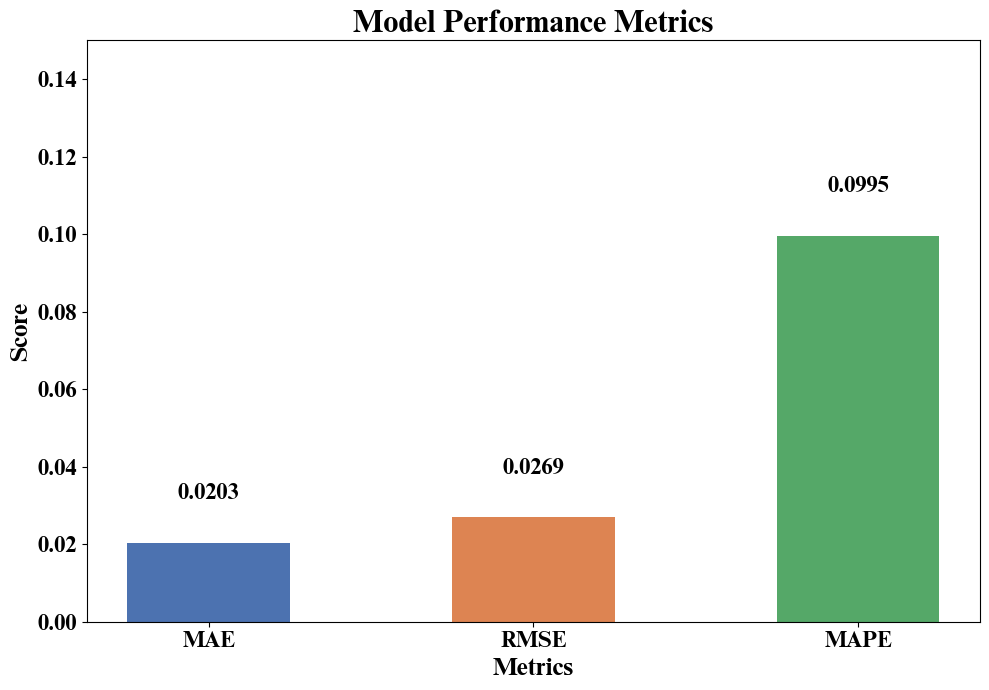

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

metrics = ['MAE', 'RMSE', 'MAPE']
values = [mae_norm, rmse_norm, smape]
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(metrics, values, color=colors, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom',
            fontproperties=fm.FontProperties(fname=font_path, size=16))

ax.set_title('Model Performance Metrics', fontproperties=font_title)
ax.set_xlabel('Metrics', fontproperties=font_label)
ax.set_ylabel('Score', fontproperties=font_label)
ax.set_ylim(0, 0.15)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

plt.tight_layout()
plt.savefig('performance_metrics.png', dpi=150)
plt.show()

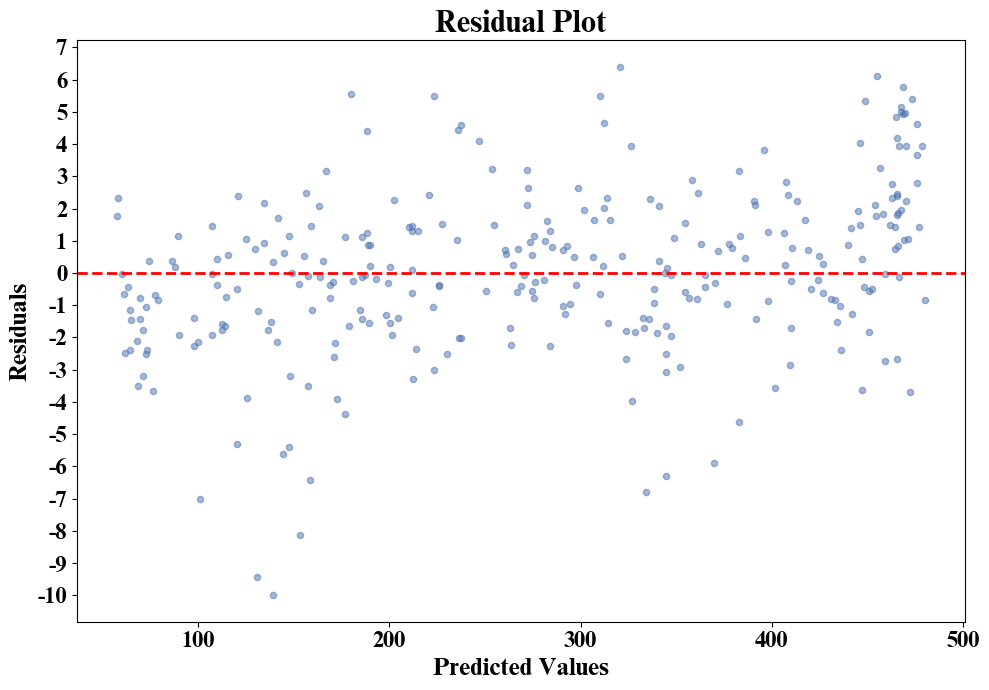

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

residuals = y_test.values - y_pred
residuals_normalized = residuals / np.max(np.abs(residuals)) * 10

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(y_pred, residuals_normalized, alpha=0.5, color='#4C72B0', s=20)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)

ax.set_title('Residual Plot', fontproperties=font_title)
ax.set_xlabel('Predicted Values', fontproperties=font_label)
ax.set_ylabel('Residuals', fontproperties=font_label)

ax.yaxis.set_major_locator(plt.MultipleLocator(1))


ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150)
plt.show()

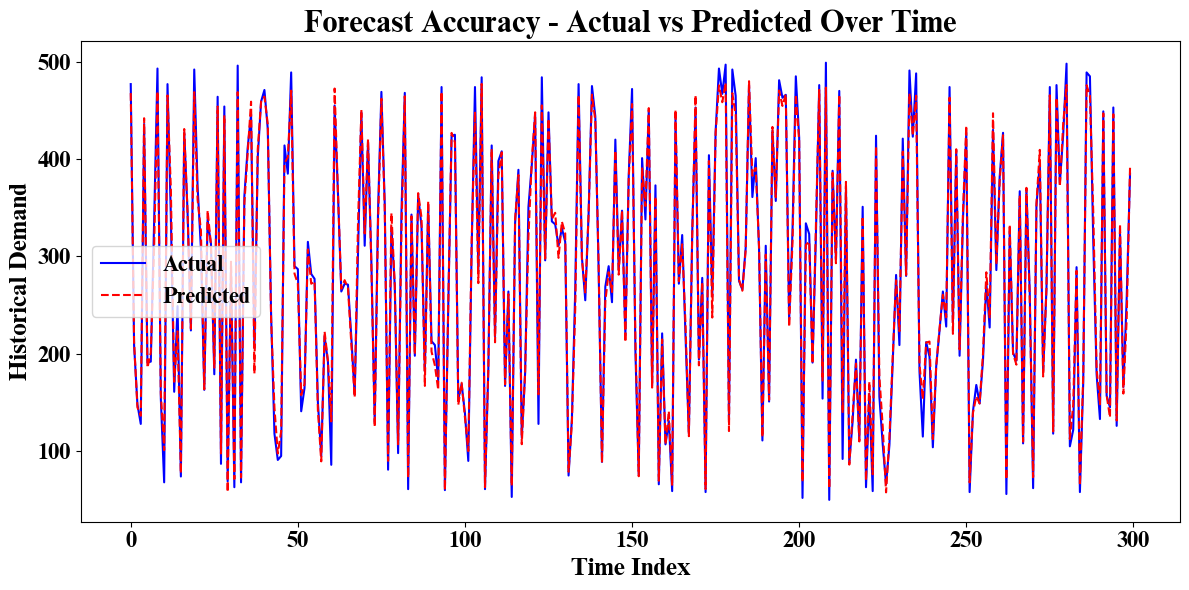

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(len(y_test)), y_test.values, label='Actual', color='blue', linewidth=1.5)
ax.plot(range(len(y_test)), y_pred, label='Predicted', color='red', linestyle='--', linewidth=1.5)

ax.set_title('Forecast Accuracy - Actual vs Predicted Over Time', fontproperties=font_title)
ax.set_xlabel('Time Index', fontproperties=font_label)
ax.set_ylabel('Historical Demand', fontproperties=font_label)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

ax.legend(prop=fm.FontProperties(fname=font_path, size=16))

plt.tight_layout()
plt.savefig('forecast_accuracy.png', dpi=150)
plt.show()

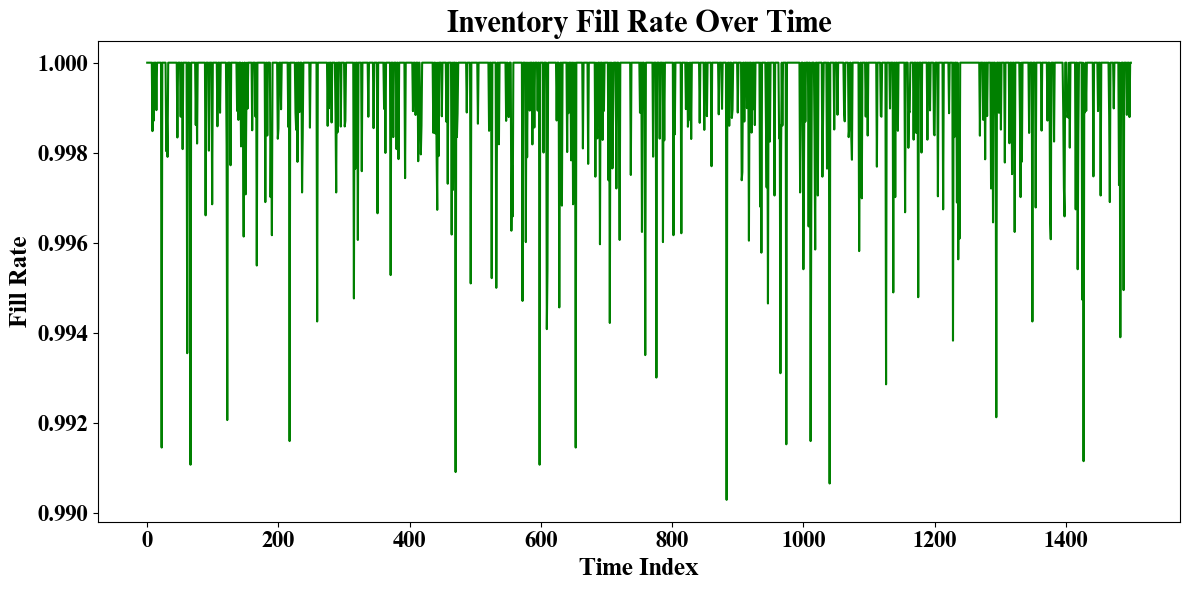

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

fill_rate = df['inventory_level'] / (df['inventory_level'] + df['stockout_flag'] + 1e-10)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(len(fill_rate)), fill_rate, color='green', linewidth=1.5)

ax.set_title('Inventory Fill Rate Over Time', fontproperties=font_title)
ax.set_xlabel('Time Index', fontproperties=font_label)
ax.set_ylabel('Fill Rate', fontproperties=font_label)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.savefig('fill_rate_line.png', dpi=150)
plt.show()

month
1     0.998986
2     0.998970
3     0.999002
4     0.998994
5     0.999053
6     0.999174
7     0.998450
8     0.998868
9     0.999207
10    0.998938
11    0.998952
12    0.998883
Name: fill_rate, dtype: float64


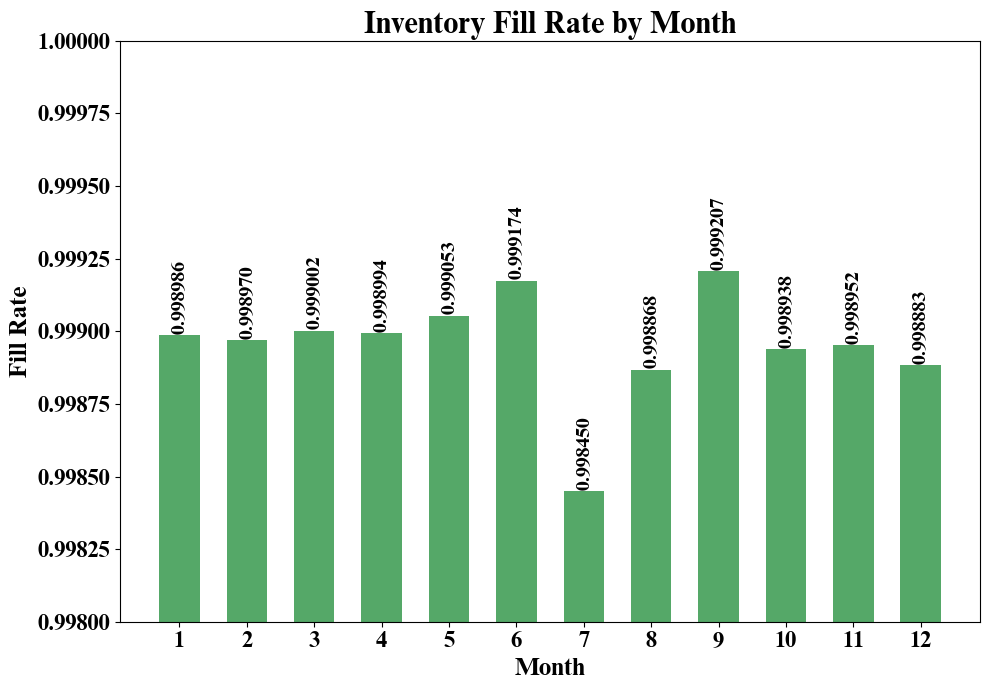

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

df['fill_rate'] = 1 - (df['stockout_flag'] / (df['historical_demand'] + 1e-10))
monthly_fill = df.groupby('month')['fill_rate'].mean()
print(monthly_fill)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(monthly_fill.index, monthly_fill.values, color='#55A868', width=0.6)

for bar, val in zip(bars, monthly_fill.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.000005,
            f'{val:.6f}', ha='center', va='bottom',
            fontproperties=fm.FontProperties(fname=font_path, size=14),
            rotation=90)

ax.set_title('Inventory Fill Rate by Month', fontproperties=font_title)
ax.set_xlabel('Month', fontproperties=font_label)
ax.set_ylabel('Fill Rate', fontproperties=font_label)
ax.set_ylim(0.998, 1.0)
ax.set_xticks(monthly_fill.index)
ax.set_xticklabels([str(i) for i in monthly_fill.index])


for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.savefig('fill_rate_bar.png', dpi=150)
plt.show()

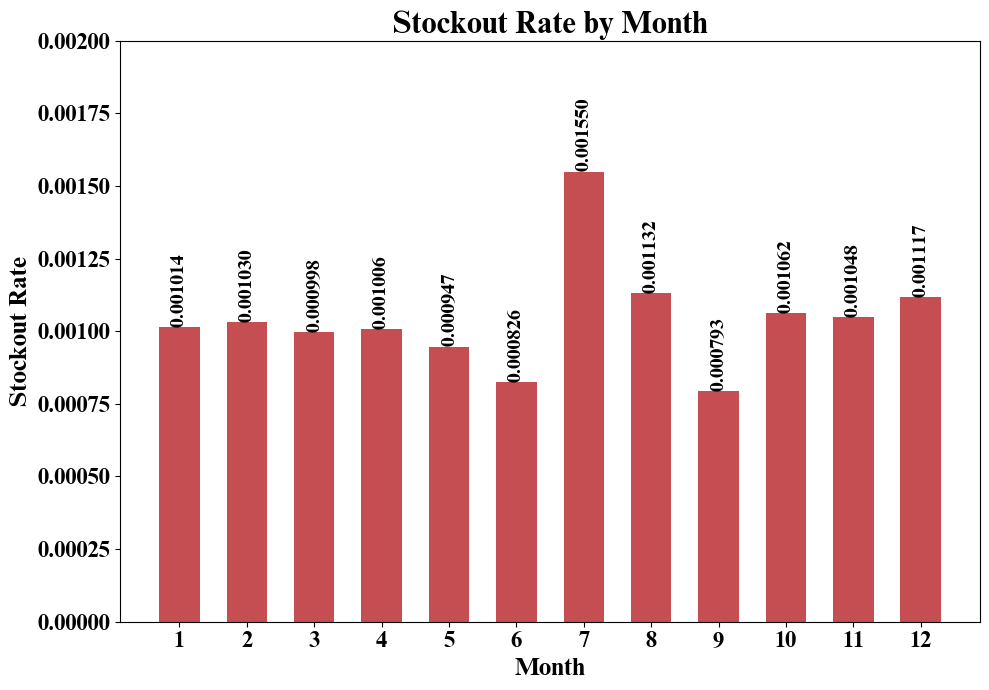

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

df['stockout_rate'] = df['stockout_flag'] / (df['historical_demand'] + 1e-10)
monthly_stockout = df.groupby('month')['stockout_rate'].mean()

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(monthly_stockout.index, monthly_stockout.values, color='#C44E52', width=0.6)

for bar, val in zip(bars, monthly_stockout.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.000001,
            f'{val:.6f}', ha='center', va='bottom',
            fontproperties=fm.FontProperties(fname=font_path, size=14),
            rotation=90)

ax.set_title('Stockout Rate by Month', fontproperties=font_title)
ax.set_xlabel('Month', fontproperties=font_label)
ax.set_ylabel('Stockout Rate', fontproperties=font_label)
ax.set_ylim(0.00000, 0.00200)
ax.set_xticks(monthly_stockout.index)
ax.set_xticklabels([str(i) for i in monthly_stockout.index])

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.savefig('stockout_rate.png', dpi=150)
plt.show()

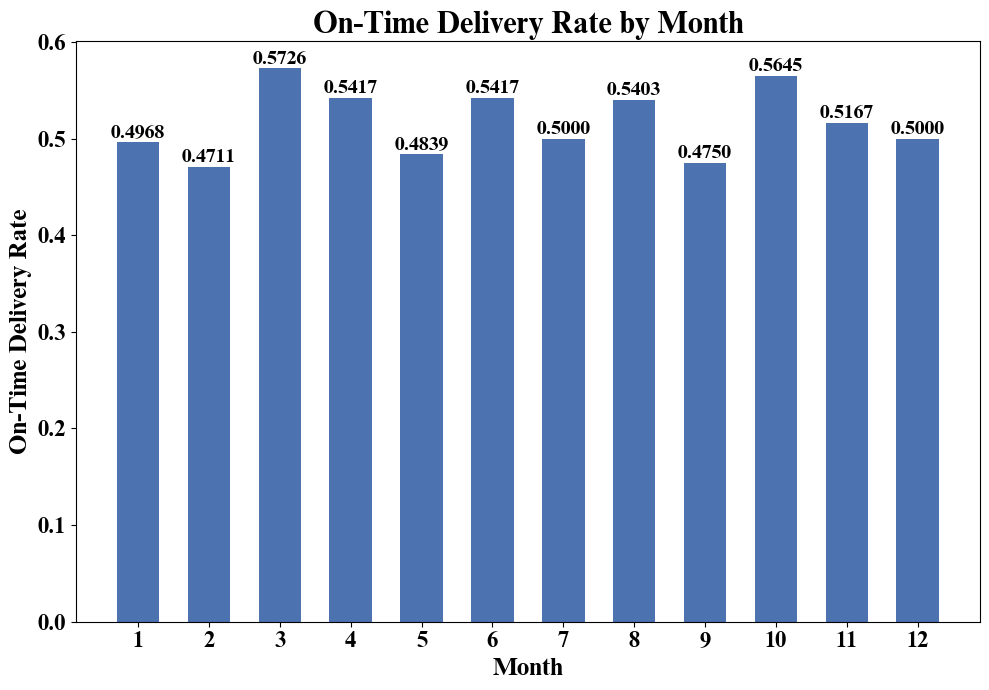

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

df['on_time_delivery'] = (df['delay_hours'] <= 24).astype(int)
monthly_otd = df.groupby('month')['on_time_delivery'].mean()

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(monthly_otd.index, monthly_otd.values, color='#4C72B0', width=0.6)

for bar, val in zip(bars, monthly_otd.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom',
            fontproperties=fm.FontProperties(fname=font_path, size=14))

ax.set_title('On-Time Delivery Rate by Month', fontproperties=font_title)
ax.set_xlabel('Month', fontproperties=font_label)
ax.set_ylabel('On-Time Delivery Rate', fontproperties=font_label)
ax.set_xticks(monthly_otd.index)
ax.set_xticklabels([str(i) for i in monthly_otd.index])

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.savefig('on_time_delivery.png', dpi=150)
plt.show()

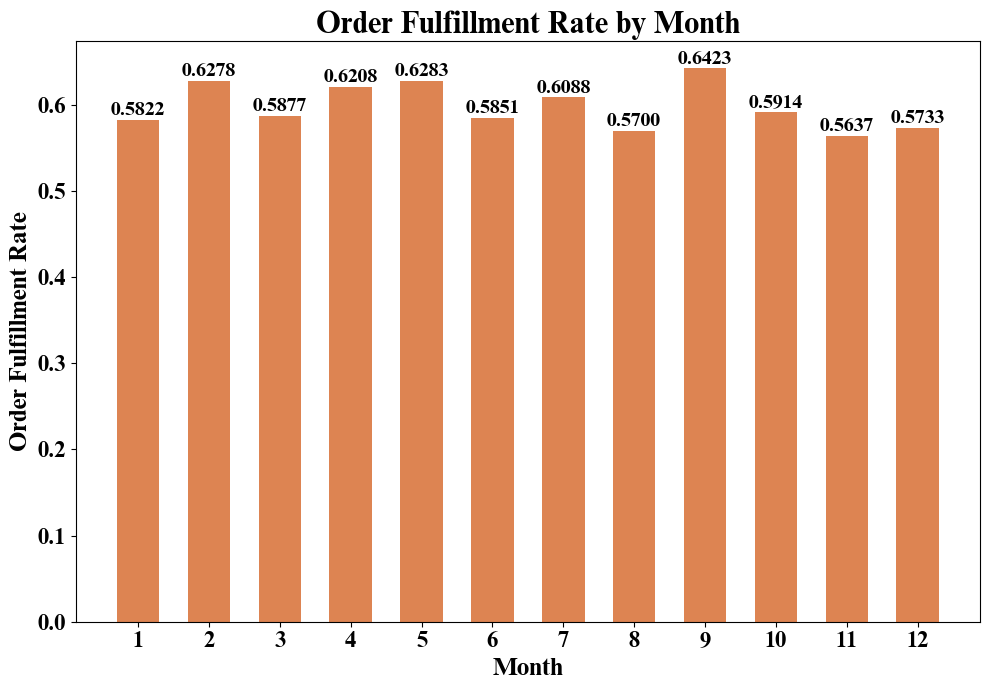

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

df['order_fulfillment'] = df['order_quantity'] / (df['historical_demand'] + 1e-10)
df['order_fulfillment'] = df['order_fulfillment'].clip(0, 1)
monthly_ofr = df.groupby('month')['order_fulfillment'].mean()

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(monthly_ofr.index, monthly_ofr.values, color='#DD8452', width=0.6)

for bar, val in zip(bars, monthly_ofr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom',
            fontproperties=fm.FontProperties(fname=font_path, size=14))

ax.set_title('Order Fulfillment Rate by Month', fontproperties=font_title)
ax.set_xlabel('Month', fontproperties=font_label)
ax.set_ylabel('Order Fulfillment Rate', fontproperties=font_label)
ax.set_xticks(monthly_ofr.index)
ax.set_xticklabels([str(i) for i in monthly_ofr.index])

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.savefig('order_fulfillment_rate.png', dpi=150)
plt.show()

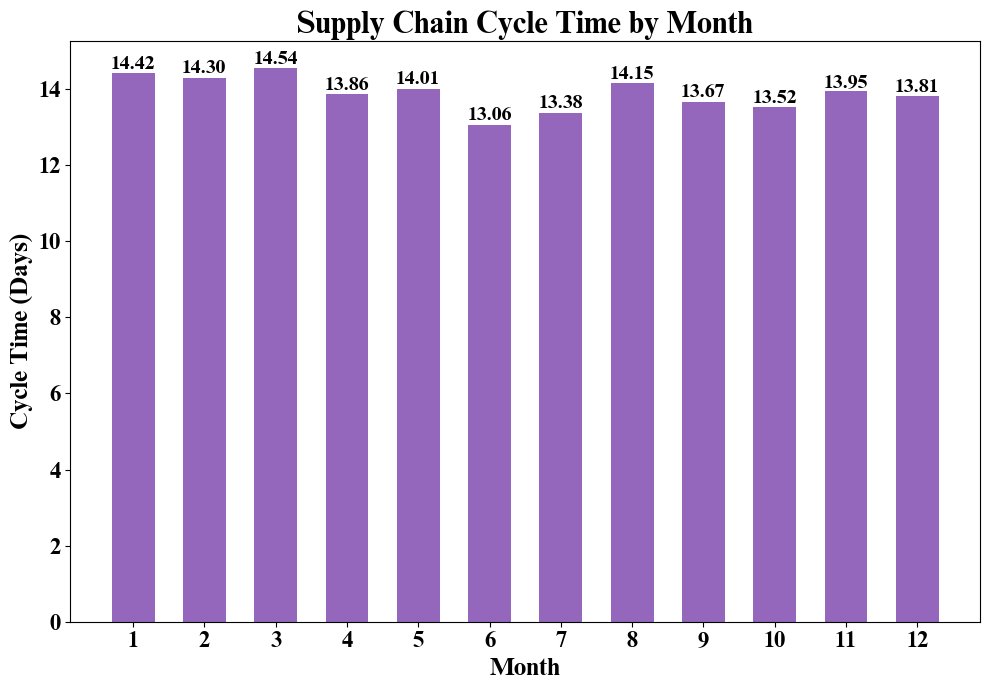

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

font_path = "/content/times new roman bold.ttf"

font_title = fm.FontProperties(fname=font_path, size=22)
font_label = fm.FontProperties(fname=font_path, size=18)
font_tick = fm.FontProperties(fname=font_path, size=16)

df['cycle_time'] = df['lead_time_days'] + df['transit_time'] + (df['delay_hours'] / 24)
monthly_cycle = df.groupby('month')['cycle_time'].mean()

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(monthly_cycle.index, monthly_cycle.values, color='#9467BD', width=0.6)

for bar, val in zip(bars, monthly_cycle.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom',
            fontproperties=fm.FontProperties(fname=font_path, size=14))

ax.set_title('Supply Chain Cycle Time by Month', fontproperties=font_title)
ax.set_xlabel('Month', fontproperties=font_label)
ax.set_ylabel('Cycle Time (Days)', fontproperties=font_label)
ax.set_xticks(monthly_cycle.index)
ax.set_xticklabels([str(i) for i in monthly_cycle.index])

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_font_properties(font_tick)

plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.savefig('supply_chain_cycle_time.png', dpi=150)
plt.show()